# Skin Lesion Classification — ResNet18/34/50 với Freeze Strategy Comparison
## HAM10000 — So sánh Transfer Learning theo kiến trúc & mức độ đóng băng layer

Notebook này kế thừa tiền xử lý đã chốt từ thí nghiệm CLAHE vs No-CLAHE trước đó,
áp dụng lên 3 kiến trúc pretrained ResNet với 3 chiến lược freeze khác nhau:

| Freeze Strategy | Mô tả | Số tham số train |
|---|---|---|
| Frozen | Đóng băng toàn bộ backbone, chỉ train lớp FC mới | Ít nhất |
| Partial | Mở khóa layer3 + layer4 + FC, đóng băng phần đầu | Trung bình |
| Full fine-tune | Mở khóa toàn bộ mạng | Nhiều nhất |

Ma trận thí nghiệm: 3 kiến trúc × 3 freeze strategy = 9 lần train, cùng data
split, cùng tiền xử lý, cùng hyperparameter cơ bản.

Dataset: HAM10000 — https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000/data

## 0. Cài đặt & Import thư viện

In [1]:
# !pip install opencv-python-headless -q

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, matthews_corrcoef, accuracy_score,
    precision_score, recall_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DX_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(DX_CLASSES)}
NUM_CLASSES = len(DX_CLASSES)

Device: cuda


## 1. Cấu hình chính thức của dự án

**QUAN TRỌNG:** Set `USE_CLAHE` theo đúng kết luận từ thí nghiệm CLAHE vs
No-CLAHE ở notebook trước (dựa trên Macro F1 / Micro-AUC cao hơn). Đây là
tiền xử lý CHÍNH THỨC cho toàn bộ notebook này — không so sánh lại CLAHE nữa,
mà dùng nó làm nền để so sánh kiến trúc + freeze strategy.

In [2]:
# ==== TIỀN XỬ LÝ CHÍNH THỨC — set theo kết luận từ notebook trước ====
USE_CLAHE = True   # đổi thành False nếu Experiment A (No-CLAHE) cho kết quả tốt hơn

IMG_SIZE = 224
BATCH_SIZE = 64        # giảm so với 128 vì ResNet nặng hơn SkinCNN, tránh tràn VRAM
EPOCHS = 10             # 9 experiment liên tiếp -> giảm epoch, tăng lại khi chốt cấu hình cuối cùng
LR = 1e-4               # nhỏ hơn 1e-3 dùng ở SkinCNN vì fine-tune pretrained cần lr thấp hơn

print(f"Tiền xử lý chính thức: {'CLAHE' if USE_CLAHE else 'Raw (No-CLAHE)'}")

Tiền xử lý chính thức: CLAHE


## 2. Cấu hình đường dẫn dữ liệu

In [3]:
def get_data_dir():
    kaggle_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
    local_path = "data"
    if os.path.isdir(kaggle_path):
        print("Đang chạy trên Kaggle")
        return kaggle_path
    print("Đang chạy local")
    return local_path

DATA_DIR = get_data_dir()
METADATA_PATH = os.path.join(DATA_DIR, "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")
IMAGE_DIRS = [
    os.path.join(DATA_DIR, "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"),
]

image_path_map = {}
for d in IMAGE_DIRS:
    if os.path.isdir(d):
        for f in glob.glob(os.path.join(d, "*.jpg")):
            image_id = os.path.splitext(os.path.basename(f))[0]
            image_path_map[image_id] = f

print(f"Tổng số ảnh tìm thấy: {len(image_path_map)}")

Đang chạy trên Kaggle
Tổng số ảnh tìm thấy: 10015


## 3. Nạp metadata & làm sạch

In [4]:
df = pd.read_csv(METADATA_PATH)
df["image_path"] = df["image_id"].map(image_path_map)

df = df[df["image_path"].notna()].reset_index(drop=True)
df = df.drop_duplicates(subset=["image_id"]).reset_index(drop=True)

age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)

df["label"] = df["dx"].map(CLASS_TO_IDX)
df = df[df["label"].notna()].reset_index(drop=True)
df["label"] = df["label"].astype(int)

print("Shape sau khi làm sạch:", df.shape)

Shape sau khi làm sạch: (10015, 9)


## 4. Chia Train/Val/Test theo lesion_id

Dùng đúng 1 bộ split cho toàn bộ 9 experiment, đảm bảo mọi kiến trúc/freeze
strategy được đánh giá trên cùng 1 tập test.

In [5]:
lesion_df = df.groupby("lesion_id").first().reset_index()[["lesion_id", "label"]]

train_lesions, temp_lesions = train_test_split(
    lesion_df, test_size=0.3, stratify=lesion_df["label"], random_state=RANDOM_STATE
)
val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=0.5, stratify=temp_lesions["label"], random_state=RANDOM_STATE
)

train_df = df[df["lesion_id"].isin(train_lesions["lesion_id"])].reset_index(drop=True)
val_df = df[df["lesion_id"].isin(val_lesions["lesion_id"])].reset_index(drop=True)
test_df = df[df["lesion_id"].isin(test_lesions["lesion_id"])].reset_index(drop=True)

print(f"Train: {len(train_df)} ảnh | Val: {len(val_df)} ảnh | Test: {len(test_df)} ảnh")

Train: 6981 ảnh | Val: 1532 ảnh | Test: 1502 ảnh


## 5. Tiền xử lý CLAHE + Augmentation + Dataset

CLAHE áp dụng trên kênh L (LAB color space) — giữ nguyên thông tin màu,
đúng như đã kết luận ở notebook trước. Augmentation giữ nguyên bộ đã dùng
để so sánh công bằng với kết quả SkinCNN.

In [6]:
import albumentations as A

def apply_clahe_rgb(img_array, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)


def get_train_augmentation():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    ])

augment_pipeline = get_train_augmentation()

# Chuẩn hóa theo ImageNet — bắt buộc vì dùng pretrained weights ImageNet
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


class SkinDataset(Dataset):
    def __init__(self, df, img_size=IMG_SIZE, augment=None, use_clahe=USE_CLAHE):
        self.paths = df["image_path"].values
        self.labels = df["label"].values
        self.img_size = (img_size, img_size)
        self.augment = augment
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = img.resize(self.img_size, Image.BILINEAR)
        arr = np.array(img)

        if self.use_clahe:
            arr = apply_clahe_rgb(arr)

        if self.augment is not None:
            arr = self.augment(image=arr)["image"]

        arr = arr.astype(np.float32) / 255.0
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD   # chuẩn hóa ImageNet — khác SkinCNN trước (chỉ chia 255)
        tensor = torch.tensor(arr, dtype=torch.float32).permute(2, 0, 1)
        return tensor, int(self.labels[idx])


train_ds = SkinDataset(train_df, augment=augment_pipeline)
val_ds   = SkinDataset(val_df, augment=None)
test_ds  = SkinDataset(test_df, augment=None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 6981 | Val: 1532 | Test: 1502


## 6. Model builder: ResNet18/34/50 + Freeze Strategy

Hàm `build_resnet` nhận 2 tham số: kiến trúc và chiến lược freeze — trả về
model đã sẵn sàng train, với đúng số layer được mở khóa theo strategy.

In [7]:
RESNET_VARIANTS = {
    "ResNet18": (models.resnet18, models.ResNet18_Weights.DEFAULT),
    "ResNet34": (models.resnet34, models.ResNet34_Weights.DEFAULT),
    "ResNet50": (models.resnet50, models.ResNet50_Weights.DEFAULT),
}

FREEZE_STRATEGIES = ["frozen", "partial", "full"]


def build_resnet(variant_name, freeze_strategy, num_classes=NUM_CLASSES, seed=RANDOM_STATE):
    """
    freeze_strategy:
      - 'frozen'  : đóng băng toàn bộ backbone, chỉ train FC mới thêm vào
      - 'partial' : mở khóa layer3 + layer4 + FC, đóng băng phần đầu (conv1, bn1, layer1, layer2)
      - 'full'    : mở khóa toàn bộ mạng, fine-tune từ đầu đến cuối
    """
    torch.manual_seed(seed)  # đảm bảo lớp FC mới khởi tạo giống nhau giữa các experiment

    model_fn, weights = RESNET_VARIANTS[variant_name]
    model = model_fn(weights=weights)

    # Thay lớp FC cuối cho đúng số lớp bài toán (7 lớp)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes),
    )

    # --- Áp dụng freeze strategy ---
    if freeze_strategy == "frozen":
        for name, param in model.named_parameters():
            param.requires_grad = "fc" in name

    elif freeze_strategy == "partial":
        for name, param in model.named_parameters():
            param.requires_grad = any(k in name for k in ["layer3", "layer4", "fc"])

    elif freeze_strategy == "full":
        for param in model.parameters():
            param.requires_grad = True

    else:
        raise ValueError(f"Freeze strategy không hợp lệ: {freeze_strategy}")

    model = model.to(DEVICE)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"[{variant_name} | {freeze_strategy}] Trainable params: {trainable:,} / {total:,} "
          f"({trainable/total*100:.1f}%)")

    return model

## 7. Hàm Train & Evaluate dùng chung (tái sử dụng từ notebook trước)

In [8]:
def compute_class_weights(train_ds, num_classes=NUM_CLASSES, method="sqrt"):
    labels_all = torch.tensor(train_ds.labels.astype(int))
    counts_t = torch.bincount(labels_all, minlength=num_classes).float()
    weights = 1.0 / torch.sqrt(counts_t) if method == "sqrt" else 1.0 / counts_t
    weights = weights / weights.sum() * num_classes
    return weights


def train_model(model, train_loader, val_loader, class_weights, epochs=EPOCHS, lr=LR, exp_name=""):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    # chỉ optimize những tham số có requires_grad=True (đúng theo freeze strategy)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    hist = {k: [] for k in ["tl", "ta", "vl", "va"]}

    for ep in range(epochs):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += len(xb)
        scheduler.step()

        model.eval()
        v_loss_sum, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out, yb)
                v_loss_sum += loss.item() * len(xb)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_total += len(xb)

        hist["tl"].append(loss_sum / total)
        hist["ta"].append(correct / total)
        hist["vl"].append(v_loss_sum / v_total)
        hist["va"].append(v_correct / v_total)

        print(f"[{exp_name}] Epoch {ep+1:2d}/{epochs} | "
              f"Loss: {loss_sum/total:.4f}/{v_loss_sum/v_total:.4f} | "
              f"Acc: {correct/total:.4f}/{v_correct/v_total:.4f}")

    return hist


def evaluate_model(model, test_loader, exp_name=""):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            all_logits.append(out.cpu())
            all_labels.append(yb)

    logits = torch.cat(all_logits)
    y_true = torch.cat(all_labels).numpy()
    y_pred = logits.argmax(1).numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"[{exp_name}] Acc={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | "
          f"F1={f1:.4f} | MCC={mcc:.4f}")

    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "mcc": mcc,
        "y_true": y_true, "y_pred": y_pred,
    }

## 8. Chạy ma trận thí nghiệm: 3 kiến trúc × 3 freeze strategy

Vòng lặp lồng nhau chạy toàn bộ 9 experiment, lưu kết quả vào 1 list để
tổng hợp bảng so sánh cuối cùng. Mỗi experiment build model mới hoàn toàn
(không tái dùng trọng số đã train), đảm bảo độc lập giữa các lần chạy.

In [9]:
class_weights = compute_class_weights(train_ds)

all_results = []
all_histories = {}

for variant_name in RESNET_VARIANTS:
    for freeze_strategy in FREEZE_STRATEGIES:
        exp_name = f"{variant_name}_{freeze_strategy}"
        print(f"\n{'='*25} {exp_name} {'='*25}")

        model = build_resnet(variant_name, freeze_strategy)
        hist = train_model(model, train_loader, val_loader, class_weights, exp_name=exp_name)
        result = evaluate_model(model, test_loader, exp_name=exp_name)

        result.update({"model": variant_name, "freeze": freeze_strategy})
        all_results.append(result)
        all_histories[exp_name] = hist

        # Giải phóng bộ nhớ GPU giữa các experiment
        del model
        torch.cuda.empty_cache()


========================= ResNet18_frozen =========================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


[ResNet18 | frozen] Trainable params: 3,591 / 11,180,103 (0.0%)
[ResNet18_frozen] Epoch  1/10 | Loss: 1.8391/1.2350 | Acc: 0.4978/0.6632
[ResNet18_frozen] Epoch  2/10 | Loss: 1.6641/1.1401 | Acc: 0.5998/0.6802
[ResNet18_frozen] Epoch  3/10 | Loss: 1.6102/1.0978 | Acc: 0.6303/0.6749
[ResNet18_frozen] Epoch  4/10 | Loss: 1.5730/1.0894 | Acc: 0.6304/0.6769
[ResNet18_frozen] Epoch  5/10 | Loss: 1.5026/1.0453 | Acc: 0.6442/0.6802
[ResNet18_frozen] Epoch  6/10 | Loss: 1.4701/1.0149 | Acc: 0.6519/0.6919
[ResNet18_frozen] Epoch  7/10 | Loss: 1.4804/1.0119 | Acc: 0.6455/0.6893
[ResNet18_frozen] Epoch  8/10 | Loss: 1.4436/1.0310 | Acc: 0.6492/0.6847
[ResNet18_frozen] Epoch  9/10 | Loss: 1.4357/1.0165 | Acc: 0.6488/0.6886
[ResNet18_frozen] Epoch 10/10 | Loss: 1.4351/1.0253 | Acc: 0.6554/0.6847
[ResNet18_frozen] Acc=0.6897 | Precision=0.3736 | Recall=0.3073 | F1=0.3160 | MCC=0.3817

========================= ResNet18_partial =========================
[ResNet18 | partial] Trainable params: 10,497,0

100%|██████████| 83.3M/83.3M [00:00<00:00, 202MB/s]


[ResNet34 | frozen] Trainable params: 3,591 / 21,288,263 (0.0%)
[ResNet34_frozen] Epoch  1/10 | Loss: 1.9087/1.2894 | Acc: 0.4174/0.6456
[ResNet34_frozen] Epoch  2/10 | Loss: 1.7125/1.2163 | Acc: 0.5784/0.6501
[ResNet34_frozen] Epoch  3/10 | Loss: 1.6358/1.1594 | Acc: 0.5986/0.6586
[ResNet34_frozen] Epoch  4/10 | Loss: 1.5917/1.1072 | Acc: 0.6081/0.6684
[ResNet34_frozen] Epoch  5/10 | Loss: 1.5457/1.0965 | Acc: 0.6268/0.6697
[ResNet34_frozen] Epoch  6/10 | Loss: 1.5110/1.0873 | Acc: 0.6286/0.6691
[ResNet34_frozen] Epoch  7/10 | Loss: 1.5129/1.0624 | Acc: 0.6376/0.6775
[ResNet34_frozen] Epoch  8/10 | Loss: 1.4832/1.0598 | Acc: 0.6356/0.6723
[ResNet34_frozen] Epoch  9/10 | Loss: 1.5068/1.0594 | Acc: 0.6276/0.6769
[ResNet34_frozen] Epoch 10/10 | Loss: 1.4582/1.0449 | Acc: 0.6426/0.6769
[ResNet34_frozen] Acc=0.6784 | Precision=0.2547 | Recall=0.2458 | F1=0.2473 | MCC=0.3177

========================= ResNet34_partial =========================
[ResNet34 | partial] Trainable params: 19,940,3

100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


[ResNet50 | frozen] Trainable params: 14,343 / 23,522,375 (0.1%)
[ResNet50_frozen] Epoch  1/10 | Loss: 1.7034/1.3498 | Acc: 0.6109/0.6645
[ResNet50_frozen] Epoch  2/10 | Loss: 1.5659/1.2666 | Acc: 0.6724/0.6762
[ResNet50_frozen] Epoch  3/10 | Loss: 1.5223/1.2517 | Acc: 0.6839/0.6854
[ResNet50_frozen] Epoch  4/10 | Loss: 1.4689/1.2111 | Acc: 0.6900/0.7010
[ResNet50_frozen] Epoch  5/10 | Loss: 1.4329/1.1434 | Acc: 0.6990/0.7037
[ResNet50_frozen] Epoch  6/10 | Loss: 1.4108/1.1610 | Acc: 0.6975/0.6932
[ResNet50_frozen] Epoch  7/10 | Loss: 1.3987/1.1258 | Acc: 0.7016/0.6952
[ResNet50_frozen] Epoch  8/10 | Loss: 1.3816/1.1376 | Acc: 0.7056/0.6919
[ResNet50_frozen] Epoch  9/10 | Loss: 1.3802/1.1657 | Acc: 0.7049/0.6978
[ResNet50_frozen] Epoch 10/10 | Loss: 1.3786/1.1208 | Acc: 0.7019/0.6965
[ResNet50_frozen] Acc=0.7084 | Precision=0.4770 | Recall=0.2683 | F1=0.2718 | MCC=0.3876

========================= ResNet50_partial =========================
[ResNet50 | partial] Trainable params: 22,077,

In [10]:
sample_paths = df["image_path"].dropna().sample(min(200, len(df)), random_state=RANDOM_STATE)
sizes = set()
for p in sample_paths:
    with Image.open(p) as im:
        sizes.add(im.size)
print("Kích thước ảnh gốc (mẫu 200 ảnh):", sizes)

Kích thước ảnh gốc (mẫu 200 ảnh): {(600, 450)}


## 9. Bảng tổng hợp kết quả 9 experiment

In [11]:
results_df = pd.DataFrame(all_results)[
    ["model", "freeze", "accuracy", "precision", "recall", "f1", "mcc"]
].round(4)
results_df = results_df.sort_values(["model", "freeze"]).reset_index(drop=True)
print(results_df.to_string(index=False))

os.makedirs("experiments", exist_ok=True)
results_df.to_csv("experiments/resnet_freeze_comparison.csv", index=False)

   model  freeze  accuracy  precision  recall     f1    mcc
ResNet18  frozen    0.6897     0.3736  0.3073 0.3160 0.3817
ResNet18    full    0.8169     0.6836  0.6886 0.6808 0.6508
ResNet18 partial    0.7989     0.6570  0.6799 0.6636 0.6201
ResNet34  frozen    0.6784     0.2547  0.2458 0.2473 0.3177
ResNet34    full    0.8182     0.6813  0.6783 0.6779 0.6526
ResNet34 partial    0.8003     0.6505  0.6477 0.6474 0.6173
ResNet50  frozen    0.7084     0.4770  0.2683 0.2718 0.3876
ResNet50    full    0.8089     0.6659  0.6934 0.6733 0.6342
ResNet50 partial    0.8096     0.6737  0.6741 0.6706 0.6365


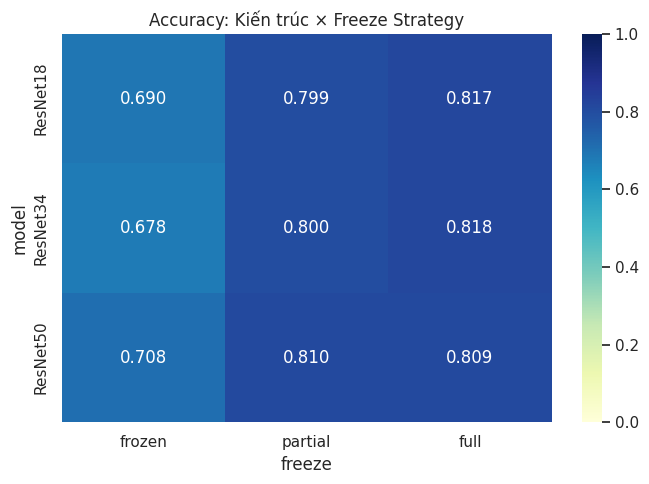

In [12]:
# Heatmap: Accuracy theo kiến trúc x freeze strategy — trực quan cho slide báo cáo
pivot_acc = results_df.pivot(index="model", columns="freeze", values="accuracy")
pivot_acc = pivot_acc[["frozen", "partial", "full"]]  # sắp xếp đúng thứ tự logic

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Accuracy: Kiến trúc × Freeze Strategy")
plt.tight_layout()
plt.show()

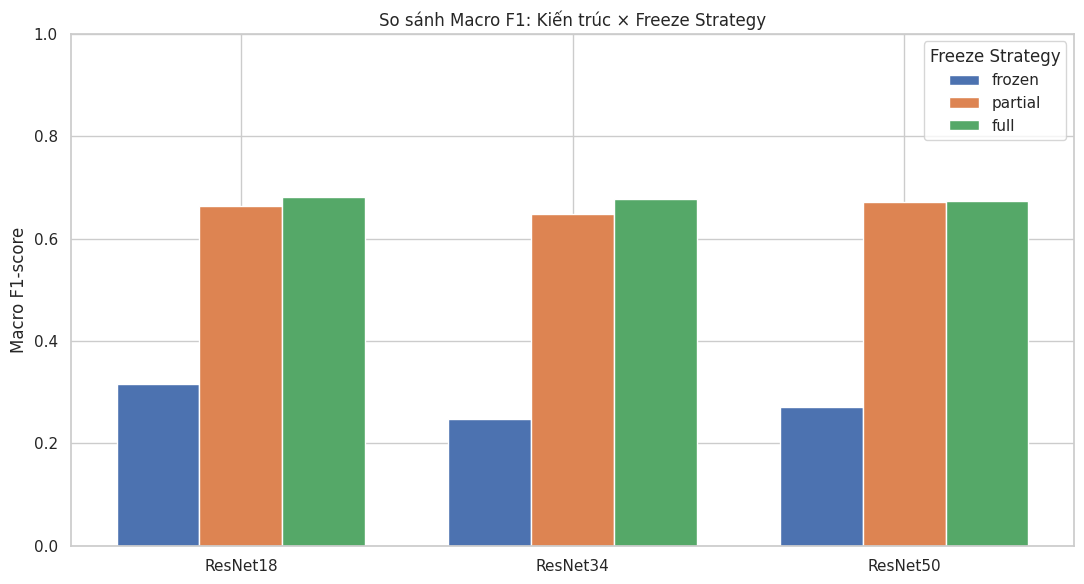

In [13]:
# Grouped bar chart: so sánh Macro F1 giữa 3 kiến trúc theo từng freeze strategy
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(RESNET_VARIANTS))
width = 0.25

for i, strategy in enumerate(FREEZE_STRATEGIES):
    vals = [results_df[(results_df["model"] == m) & (results_df["freeze"] == strategy)]["f1"].values[0]
            for m in RESNET_VARIANTS]
    ax.bar(x + (i - 1) * width, vals, width, label=strategy)

ax.set_xticks(x); ax.set_xticklabels(list(RESNET_VARIANTS.keys()))
ax.set_ylabel("Macro F1-score")
ax.set_ylim(0, 1)
ax.set_title("So sánh Macro F1: Kiến trúc × Freeze Strategy")
ax.legend(title="Freeze Strategy")
plt.tight_layout()
plt.show()

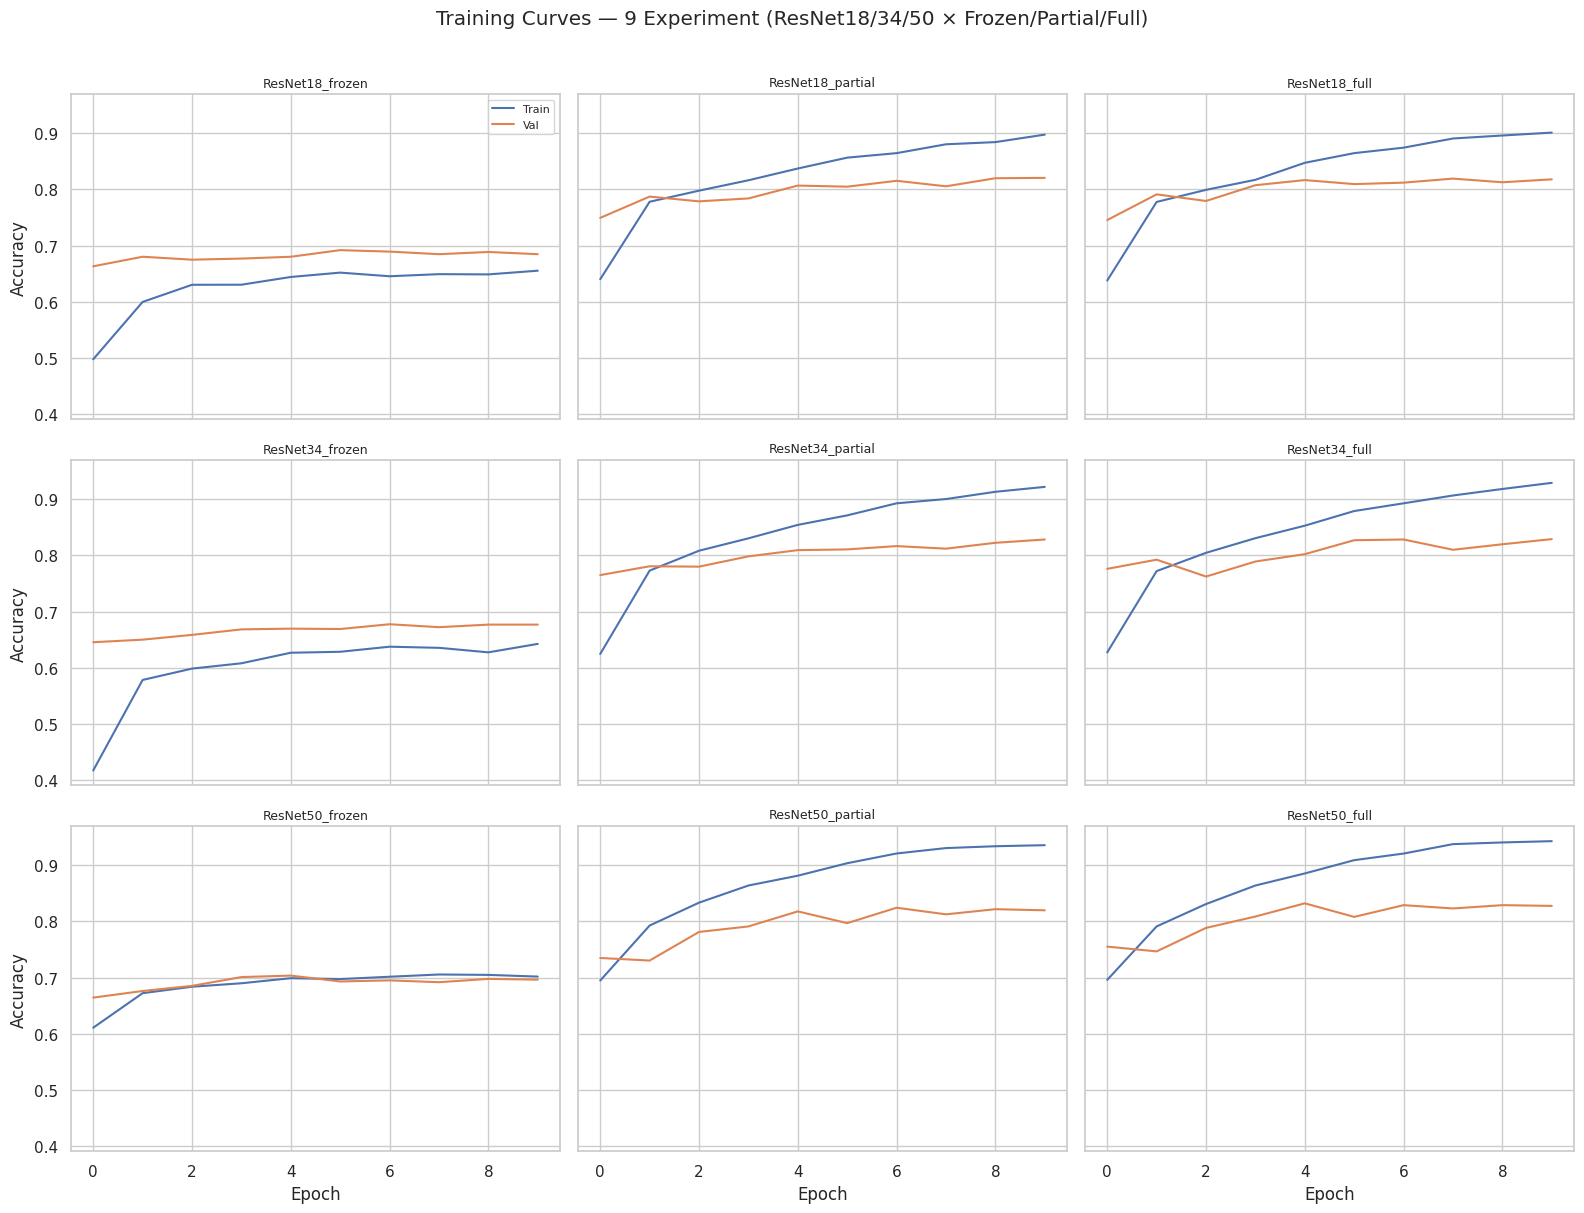

In [14]:
# Training curves của tất cả 9 experiment — xem tốc độ hội tụ khác nhau thế nào
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, variant_name in enumerate(RESNET_VARIANTS):
    for j, freeze_strategy in enumerate(FREEZE_STRATEGIES):
        exp_name = f"{variant_name}_{freeze_strategy}"
        hist = all_histories[exp_name]
        ax = axes[i, j]
        ax.plot(hist["ta"], label="Train")
        ax.plot(hist["va"], label="Val")
        ax.set_title(exp_name, fontsize=9)
        if i == 2: ax.set_xlabel("Epoch")
        if j == 0: ax.set_ylabel("Accuracy")

axes[0, 0].legend(fontsize=8)
plt.suptitle("Training Curves — 9 Experiment (ResNet18/34/50 × Frozen/Partial/Full)", y=1.01)
plt.tight_layout()
plt.show()

## 10. Confusion Matrix của model tốt nhất

Tự động chọn experiment có Macro F1 cao nhất trong bảng để phân tích sâu.

Model tốt nhất: ResNet18 — full (Macro F1 = 0.6808)


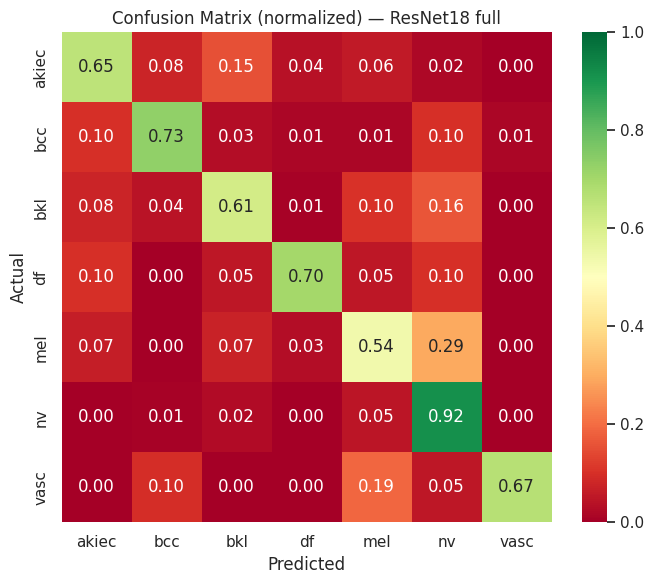

In [15]:
best_idx = results_df["f1"].idxmax()
best_row = results_df.loc[best_idx]
best_result = next(r for r in all_results
                    if r["model"] == best_row["model"] and r["freeze"] == best_row["freeze"])

print(f"Model tốt nhất: {best_row['model']} — {best_row['freeze']} "
      f"(Macro F1 = {best_row['f1']:.4f})")

cm = confusion_matrix(best_result["y_true"], best_result["y_pred"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=DX_CLASSES, yticklabels=DX_CLASSES, vmin=0, vmax=1)
plt.title(f"Confusion Matrix (normalized) — {best_row['model']} {best_row['freeze']}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()